In [25]:
import unicode
import tensorflow as tf
import cv2
import os
import pathlib
import matplotlib.pyplot as plt
import numpy as np


In [26]:
ja2label = {'ㄱ':0, 'ㄲ':1, 'ㄴ':2, 'ㄷ':3, 'ㄸ':4, 'ㄹ':5, 'ㅁ':6, 'ㅂ':7, 'ㅃ':8,
'ㅅ':9, 'ㅆ':10, 'ㅇ':11,  'ㅈ':12, 'ㅉ':13, 'ㅊ':14, 'ㅋ':15, 'ㅌ':16,  'ㅍ':17, 'ㅎ':18}

mo2label = {'ㅏ':0, 'ㅐ':1, 'ㅑ':2, 'ㅒ':3, 'ㅓ':4, 'ㅔ':5, 'ㅕ':6, 'ㅖ':7, 'ㅗ':8, 'ㅘ':9, 
'ㅙ':10, 'ㅚ':11, 'ㅛ':12, 'ㅜ':13, 'ㅝ':14, 'ㅞ':15, 'ㅟ':16, 'ㅠ':17, 'ㅡ':18, 'ㅢ':19, 'ㅣ':20}

ba2label = {None:0, 'ㄱ':1, 'ㄲ':2, 'ㄳ':3, 'ㄴ':4, 'ㄵ':5, 'ㄶ':6, 'ㄷ':7, 'ㄹ':8, 'ㄺ':9,
'ㄻ':10, 'ㄼ':11, 'ㄽ':12, 'ㄾ':13, 'ㄿ':14, 'ㅀ':15, 'ㅁ':16, 'ㅂ':17, 'ㅄ':18, 'ㅅ':19,
'ㅆ':20, 'ㅇ':21, 'ㅈ':22, 'ㅊ':23, 'ㅋ':24, 'ㅌ':25, 'ㅍ':26, 'ㅎ':27}

In [57]:
def load_label_3(label_path):
    class_names = []
    label_list = os.listdir(label_path)
    
    for label in label_list :
        
        with open(os.path.join(label_path, label), 'r') as f:
            text = f.readline()
            text = text.strip()
            print(text)
            cls = unicode.split_syllable_char(text)
            
            cls = [ja2label[cls[0]], mo2label[cls[1]], ba2label[cls[2]]]
            
            class_names.append(cls)
            
    return class_names

#def load_image(image_path):
    

def process_path(file_path, class_names, img_shape=(64,64)):
    label = class_names[0]
                   
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, img_shape)
    return img, label
    

def load_data(data_path, labelpath, batch = 32):
    class_names = load_label_3(labelpath)
    print(class_names)
    data_dir = pathlib.Path(data_path)
    print(data_dir)
    list_ds = tf.data.Dataset.list_files(str(data_dir / '*'))     
    
    for f in list_ds.take(4) :
        print(f.numpy())
    
    labeled_ds = list_ds.map(lambda x: process_path(x, class_names))
    return labeled_ds
defualt_label_parDirPath = "D:\\data\\letterTest\\"
labeled_ds = load_data(  "D:\\data\\letterTest\\image", "D:\\data\\letterTest\\label")
print(os.listdir("D:\\data\\letterTest\\image"))
for f in labeled_ds.take(4) :
    print(f)

    
  

fit(train_image, train_label)

서
제
식
킷
[[9, 4, 0], [12, 5, 0], [9, 20, 1], [15, 20, 19]]
D:\data\letterTest\image
b'D:\\data\\letterTest\\image\\2.jpg'
b'D:\\data\\letterTest\\image\\80.jpg'
b'D:\\data\\letterTest\\image\\3.jpg'
b'D:\\data\\letterTest\\image\\23.jpg'
['2.jpg', '23.jpg', '3.jpg', '80.jpg']
(<tf.Tensor: shape=(64, 64, 3), dtype=float32, numpy=
array([[[1.        , 1.        , 0.9843138 ],
        [0.973652  , 0.9789216 , 0.96060055],
        [0.976777  , 0.98284316, 0.9721201 ],
        ...,
        [0.989277  , 0.9871324 , 0.9165442 ],
        [0.986826  , 0.9816177 , 0.91488975],
        [1.        , 0.9921569 , 0.9333334 ]],

       [[0.9969976 , 1.        , 0.9813113 ],
        [0.97064954, 0.97690433, 0.9575981 ],
        [0.9751351 , 0.98120123, 0.96775717],
        ...,
        [0.9702302 , 0.9667251 , 0.89205545],
        [0.986826  , 0.9826029 , 0.9129194 ],
        [1.        , 0.9951594 , 0.92732847]],

       [[0.99368876, 0.99761033, 0.9756128 ],
        [0.96894634, 0.9771083 , 0.9535051

(64, 64, 3)


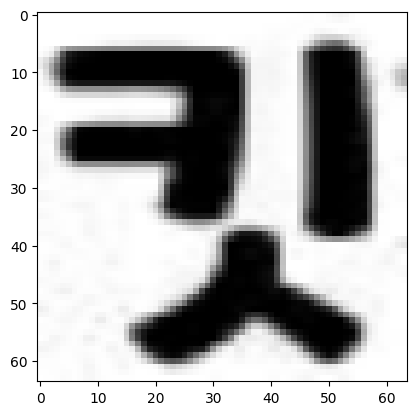

In [67]:
a = f[0].numpy()
print(a.shape)
from PIL import Image

plt.imshow(a)

# img.shape
# img.show()

In [ ]:
IMG_SIZE = 64
DATADIR = 'D:\\data\\letterTest\\testLabel.txt'

x_train = []
y_train = []

for label in LABELS:
    path = os.path.join(DATADIR, label)
    class_num = LABELS.index(label)
    
    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img))
            new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            
            x_train.append(new_array)
            y_train.append(class_num)
        except Exception as e:
            pass

In [ ]:
class Trainer:
    def __init__(self, model, epochs, batch, loss_fn, optimizer):
        self.model = model
        self.epochs = epochs
        self.batch = batch
        self.loss_fn = loss_fn
        
    def train(self, train_dataset, train_metric):
        for epoch in range(self.epochs):
            print("\nStart of epoch %d" % (epoch,))
            for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
                with tf.GradientTape() as tape:
                    logtis = model(x_batch_train, training=True)
                    loss_value = self.loss_fn(y_batch_train, logits)
                    
            grads = tape.gradient(loss_value, model.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, model.trainable_weights))
            
            train_metric.update_state(y_batch_train, logtis)
            
            if step % 5 == 0:
                print(
                    "Training loss (for one batch) at step %d : %.4f"
                    % (step, float(loss_value))
                )
                print("Seen so far : %d samples" % ((step + 1) * self.batch))
                print(train_metric.result().numpy())
                
            train_acc = train_acc_metric.result()
            print("Training acc over spoch : %.4f" % (float(train_acc),))
            
            